<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [4]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
pd.set_option('display.max_columns', None)
df.head()


--2026-04-04 19:50:45--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  47.4MB/s    in 3.4s    

2026-04-04 19:50:49 (45.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



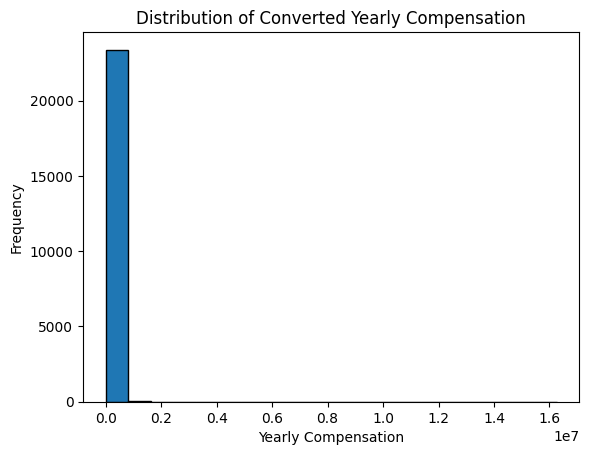

In [18]:
## Write your code here

df_plot1 = df[['ConvertedCompYearly']].dropna()
#print(len(df))
#print(len(df_plot1))

df_plot1['ConvertedCompYearly'].plot.hist(bins=20, edgecolor='black')

# Adding labels and title for clarity
plt.title('Distribution of Converted Yearly Compensation')
plt.xlabel('Yearly Compensation')
plt.ylabel('Frequency')

# Display the plot
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [19]:
## Write your code here

df_plot2 = df[['Age']].dropna()
#print(len(df))
#print(len(df_plot2))

age_mapping = {
    'Prefer not to say': 0,
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 69
}

df_plot2['AveAge'] = df_plot2['Age'].map(age_mapping)
df_plot2['AveAge'] = pd.to_numeric(df_plot2['AveAge'], errors='coerce')
print(df_plot2.head())

                  Age  AveAge
0  Under 18 years old      17
1     35-44 years old      39
2     45-54 years old      49
3     18-24 years old      21
4     18-24 years old      21


### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



<Axes: xlabel='AveAge', ylabel='ConvertedCompYearly'>

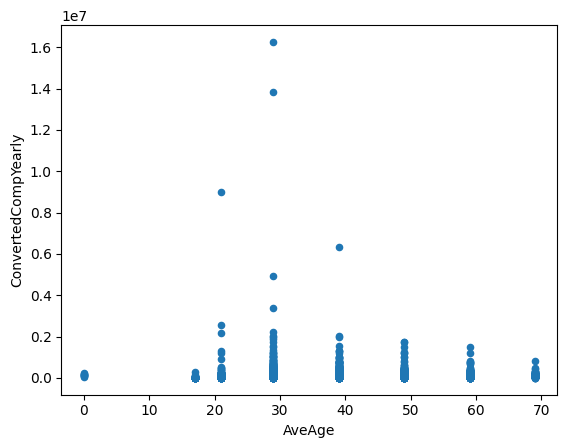

In [25]:
## Write your code here

df_plot3 = df[['Age','ConvertedCompYearly']].dropna()
#print(len(df))
#print(len(df_plot3))
#print(df_plot3.head())

age_mapping = {
    'Prefer not to say': 0,
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 69
}

df_plot3['AveAge'] = df_plot3['Age'].map(age_mapping)
df_plot3['AveAge'] = pd.to_numeric(df_plot3['AveAge'], errors='coerce')
#print(df_plot3.head())

df_plot3.plot(x= 'AveAge', y= 'ConvertedCompYearly', kind='scatter')

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


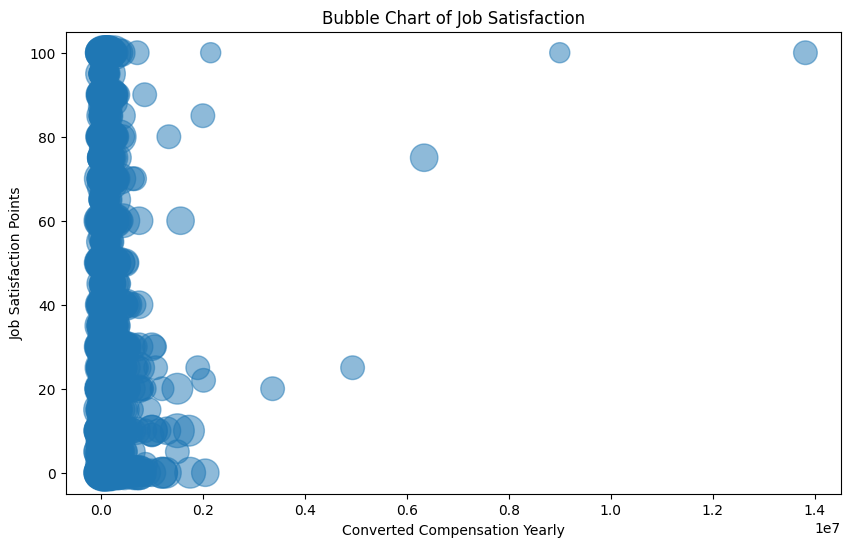

In [28]:
## Write your code here

df_plot4 = df[['Age','ConvertedCompYearly', 'JobSatPoints_6']].dropna()
#print(len(df))
#print(len(df_plot4))

age_mapping = {
    'Prefer not to say': 0,
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 69
}

df_plot4['AveAge'] = df_plot4['Age'].map(age_mapping)
df_plot4['AveAge'] = pd.to_numeric(df_plot4['AveAge'], errors='coerce')
#print(df_plot4.head())

plt.figure(figsize=(10, 6))
plt.scatter(df_plot4['ConvertedCompYearly'], 
            df_plot4['JobSatPoints_6'], 
            s=df_plot4['AveAge'] * 10, # Scaling factor for bubble size
            alpha=0.5)
plt.xlabel('Converted Compensation Yearly')
plt.ylabel('Job Satisfaction Points')
plt.title('Bubble Chart of Job Satisfaction')
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



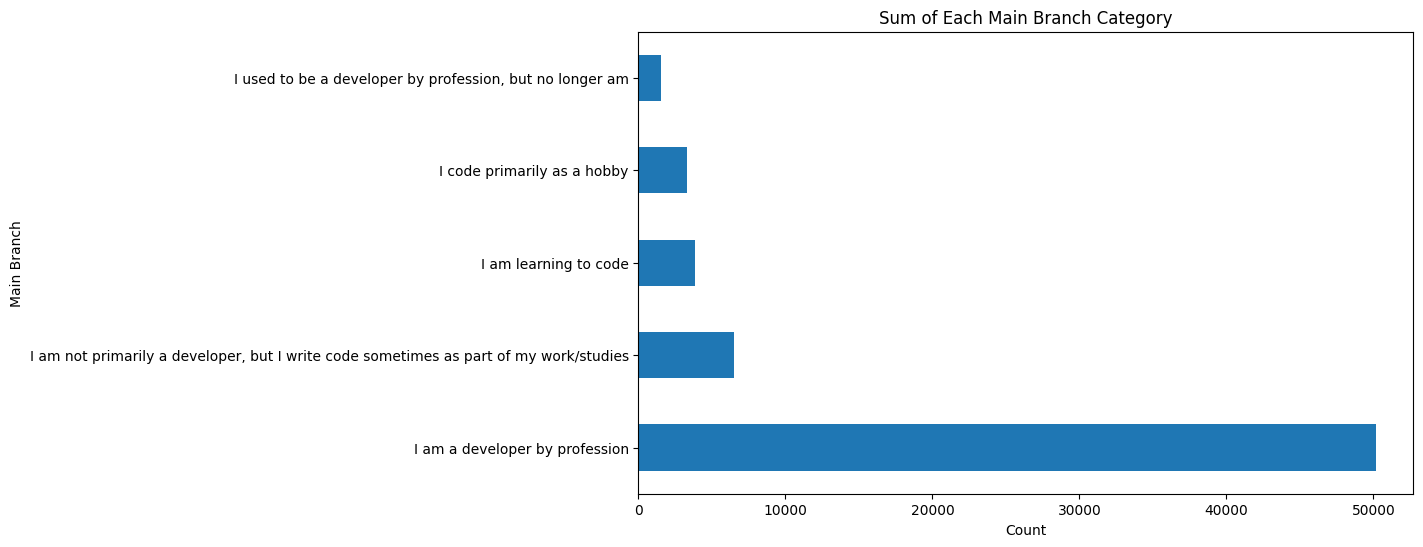

In [31]:
## Write your code here

df_plot5 = df[['MainBranch']].dropna()
#print(len(df))
#print(len(df_plot5))

# 1. Count the occurrences of each category in 'Main Branch'
main_branch_counts = df_plot5['MainBranch'].value_counts()

# 2. Plot horizontal bar chart
main_branch_counts.plot(kind='barh', figsize=(10, 6))

# 3. Add labels and title for clarity
plt.title('Sum of Each Main Branch Category')
plt.xlabel('Count')
plt.ylabel('Main Branch')
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



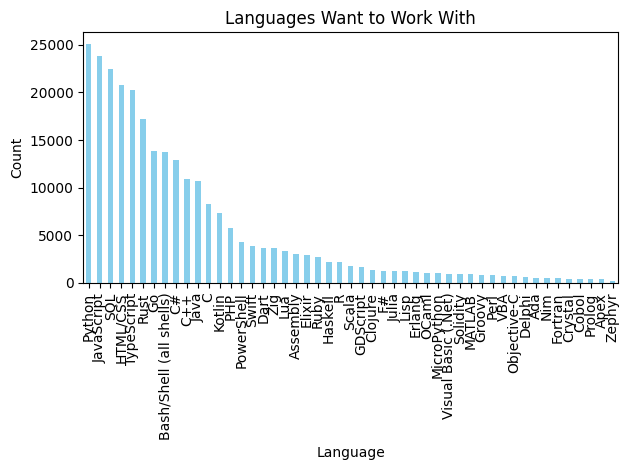

In [34]:
## Write your code here

df_plot6 = df[['LanguageWantToWorkWith']].dropna()
#print(len(df))
#print(len(df_plot6))

df_plot6['LanguageWantToWorkWith'] = df_plot6['LanguageWantToWorkWith'].str.split(';')
exploded_df = df_plot6.explode('LanguageWantToWorkWith')

# 3. Sum/Count unique values
language_counts = exploded_df['LanguageWantToWorkWith'].value_counts()

# 4. Plot the counts
language_counts.plot(kind='bar', color='skyblue', title='Languages Want to Work With')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


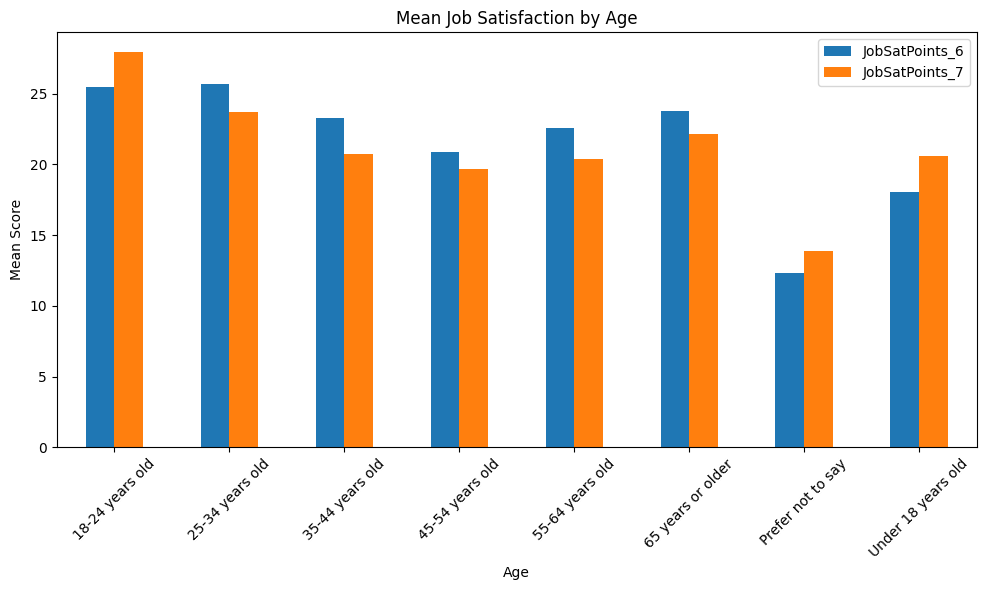

In [35]:
## Write your code here

df_plot7 = df[['JobSatPoints_6', 'JobSatPoints_7', 'Age']].dropna()
#print(len(df))
#print(len(df_plot7))

# Group by 'Age' and calculate the mean for the job satisfaction columns
grouped_data = df_plot7.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].mean()

# Plot the mean values (bar plot is typically best for this)
grouped_data.plot(kind='bar', figsize=(10, 6))

# Add titles and labels
plt.title('Mean Job Satisfaction by Age')
plt.ylabel('Mean Score')
plt.xlabel('Age')
plt.xticks(rotation=45)
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])
plt.tight_layout()

# Show the plot
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



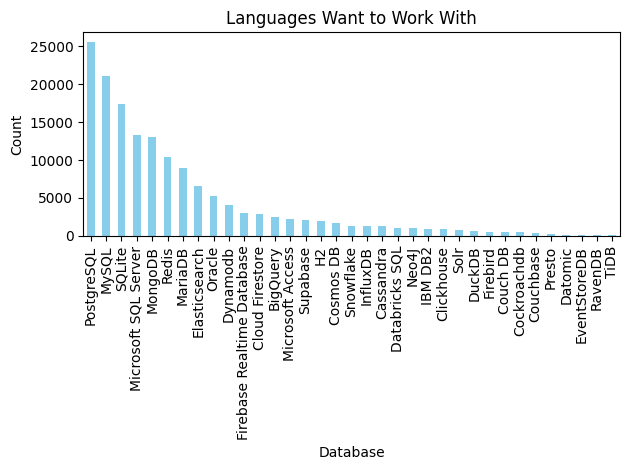

In [37]:
## Write your code here

df_plot8 = df[['DatabaseHaveWorkedWith']].dropna()
#print(len(df))
#print(len(df_plot8))

df_plot8['DatabaseHaveWorkedWith'] = df_plot8['DatabaseHaveWorkedWith'].str.split(';')
exploded_df = df_plot8.explode('DatabaseHaveWorkedWith')

# 3. Sum/Count unique values
database_counts = exploded_df['DatabaseHaveWorkedWith'].value_counts()

# 4. Plot the counts
database_counts.plot(kind='bar', color='skyblue', title='Languages Want to Work With')
plt.xlabel('Database')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



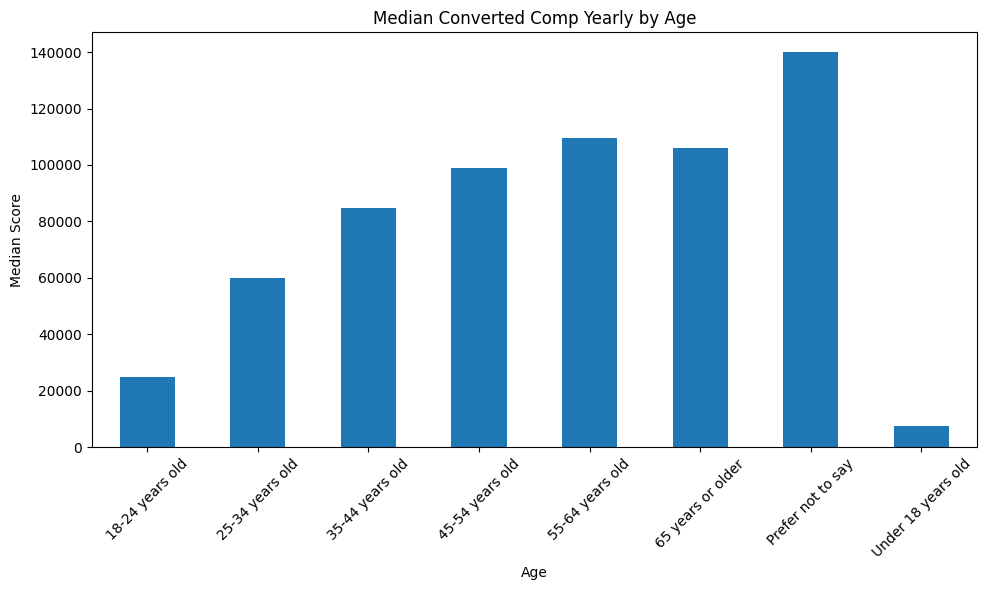

In [41]:
## Write your code here

df_plot9 = df[['ConvertedCompYearly', 'Age']].dropna()
#print(len(df))
#print(len(df_plot9))

# Group by 'Age' and calculate the mean for the job satisfaction columns
grouped_data = df_plot9.groupby('Age')['ConvertedCompYearly'].median()

# Plot the mean values (bar plot is typically best for this)
grouped_data.plot(kind='bar', figsize=(10, 6))

# Add titles and labels
plt.title('Median Converted Comp Yearly by Age')
plt.ylabel('Median Score')
plt.xlabel('Age')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



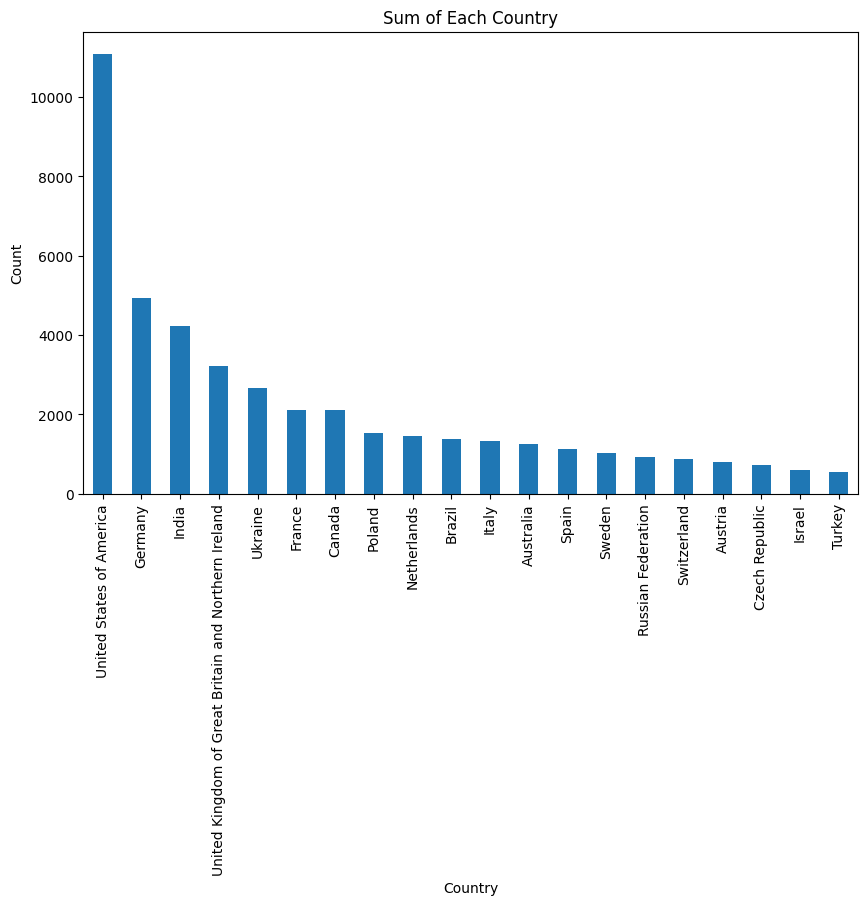

In [44]:
## Write your code here

df_plot10 = df[['Country']].dropna()
#print(len(df))
#print(len(df_plot10))

# 1. Count the occurrences of each category in 'Country'
country_counts = df_plot10['Country'].value_counts()
top20_country = country_counts[:20]

# 2. Plot horizontal bar chart
#country_counts.plot(kind='bar', figsize=(10, 6))
top20_country.plot(kind='bar', figsize=(10, 6))

# 3. Add labels and title for clarity
plt.title('Sum of Each Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
